In [75]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import muon as mu
import os

In [76]:
data_dir = "/Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/PBMC_healthy_donor_granulocyte_10K/rna"

In [77]:
mdata = mu.read_10x_h5(os.path.join(data_dir, "filtered_feature_bc_matrix.h5"))
mdata.var_names_make_unique()
mdata

/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Added `interval` annotation for features from /Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/PBMC_healthy_donor_granulocyte_10K/rna/filtered_feature_bc_matrix.h5


/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/mudata/_core/mudata.py:571: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/Users/siddharthadas/miniconda3/envs/scanp

MuData object with n_obs × n_vars = 11909 × 144978
  var:	'gene_ids', 'feature_types', 'genome', 'interval'
  2 modalities
    rna:	11909 x 36601
      var:	'gene_ids', 'feature_types', 'genome', 'interval'
    atac:	11909 x 108377
      var:	'gene_ids', 'feature_types', 'genome', 'interval'

In [78]:
rna = mdata.mod['rna']
rna


AnnData object with n_obs × n_vars = 11909 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

In [79]:
rna.var['mt'] = rna.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(rna, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

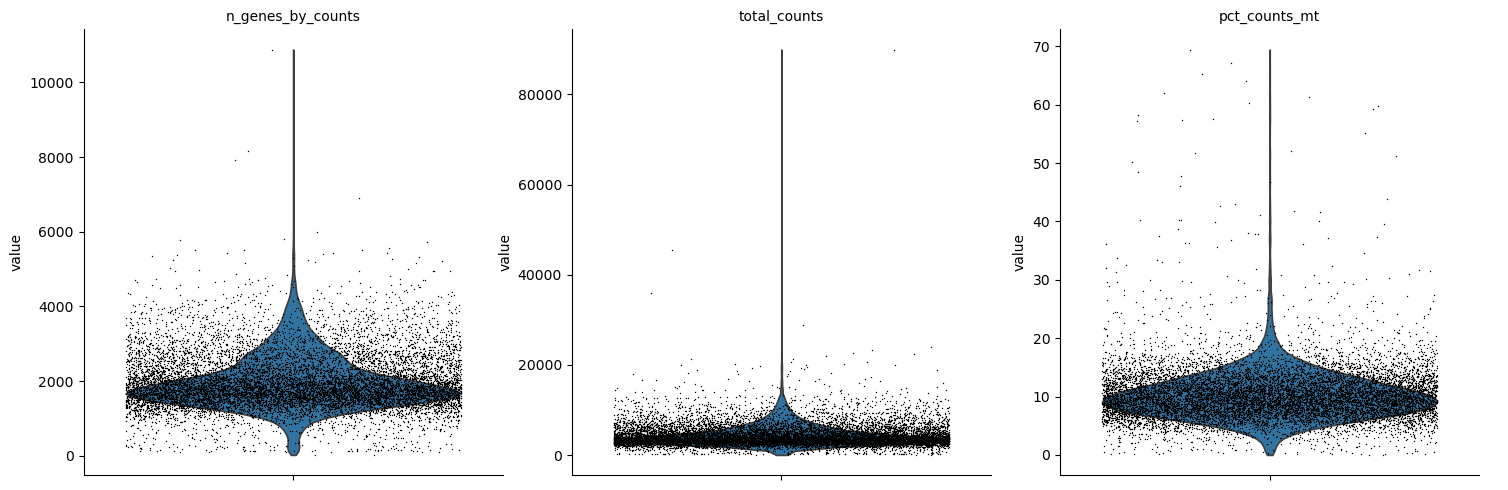

In [80]:
sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [ ]:
Filter genes which expression is not detected

In [81]:
sc.pp.filter_genes(rna, min_cells = 3)
# This is analogous to
#   sc.pp.filter_genes(rna, min_cells=3)
# but does in-place filtering and avoids copying the object

In [ ]:
Filter cells

In [82]:
mu.pp.filter_obs(rna, 'n_genes_by_counts', lambda x: (x >= 200) & (x < 5000))
# This is analogous to
#   sc.pp.filter_cells(rna, min_genes=200)
#   rna = rna[rna.obs.n_genes_by_counts < 5000, :]
# but does in-place filtering avoiding copying the object

mu.pp.filter_obs(rna, 'total_counts', lambda x: x < 15000)
mu.pp.filter_obs(rna, 'pct_counts_mt', lambda x: x < 20)

In [ ]:
Let’s see how the data looks after filtering

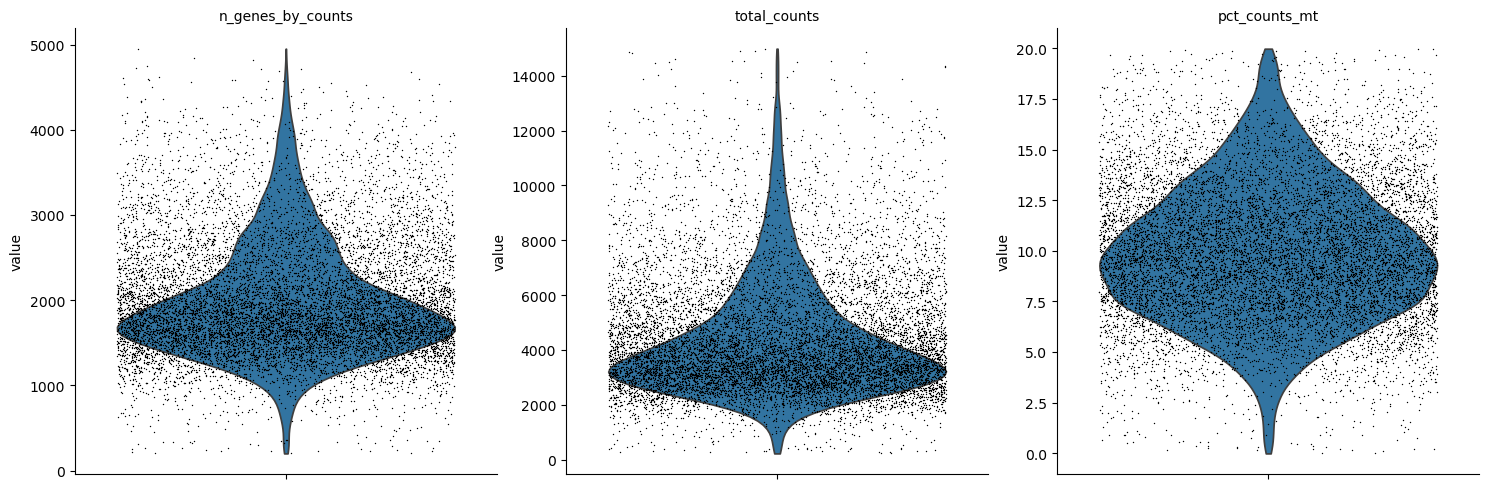

In [83]:
sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [ ]:
Normalisation
We’ll normalise the data so that we get log-normalised counts to work with.

In [84]:
sc.pp.normalize_total(rna, target_sum=1e4)

In [85]:
sc.pp.log1p(rna)

In [ ]:
Feature selection
We will label highly variable genes that we’ll use for downstream analysis.

In [86]:
sc.pp.highly_variable_genes(rna, min_mean=0.02, max_mean=4, min_disp=0.5)

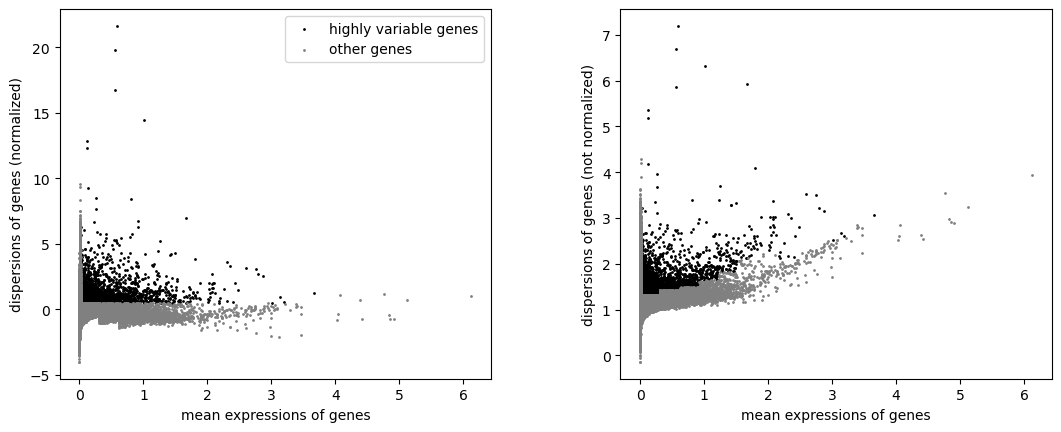

In [87]:
sc.pl.highly_variable_genes(rna)

In [88]:
np.sum(rna.var.highly_variable)

3026

In [ ]:
Scaling
We’ll save log-normalised counts in a .raw slot:

In [89]:
rna.raw = rna

In [ ]:
and scale the log-normalised counts to zero mean and unit variance:

In [90]:
sc.pp.scale(rna, max_value=10)

/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
Analysis
Having filtered low-quality cells, normalised the counts matrix, and performed feature selection, we can already use this data for multimodal integration.

However it is usually a good idea to study individual modalities as well. Below we run PCA on the scaled matrix, compute cell neighbourhood graph, and perform clustering to define cell types.

In [ ]:
PCA and neighbourhood graph


In [91]:
sc.tl.pca(rna, svd_solver='arpack')

In [ ]:
To visualise the result, we will use some markers for (large-scale) cell populations we expect to see such as T cells and NK cells (CD2), 
B cells (CD79A), and KLF4 (monocytes).

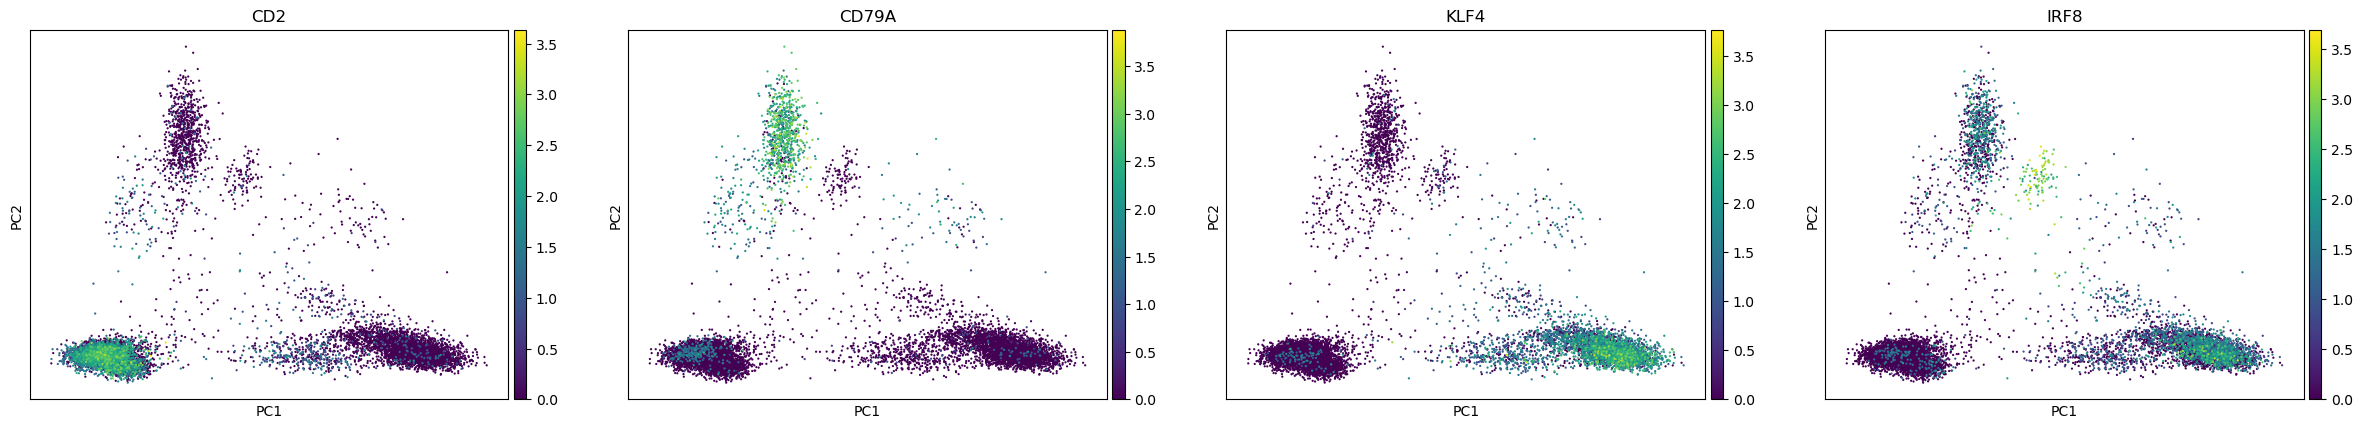

In [92]:
sc.pl.pca(rna, color=['CD2', 'CD79A', 'KLF4', 'IRF8'])

In [ ]:
The first principal component (PC1) is separating myeloid (monocytes) and lymphoid (T, B, NK) cells while B cells-related features seem to
drive the second one. Also we see plasmocytoid dendritic cells (marked by IRF8) being close to B cells along the PC2.

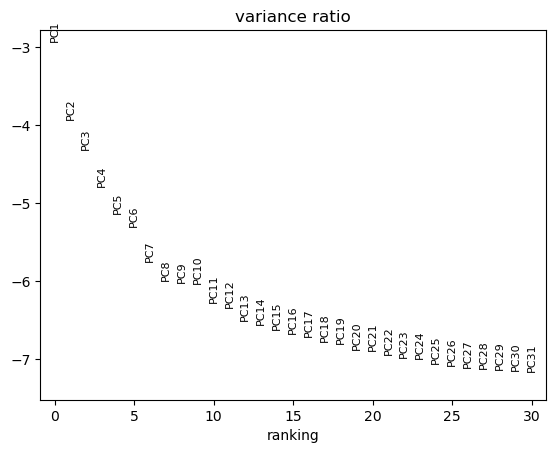

In [93]:
sc.pl.pca_variance_ratio(rna, log=True)

In [ ]:
Now we can compute a neighbourhood graph for cells

In [94]:
sc.pp.neighbors(rna, n_neighbors=10, n_pcs=20)

In [ ]:
Non-linear dimensionality reduction and clustering

In [ ]:
With the neighbourhood graph computed, we can now perform clustering. We will use leiden clustering as an example.



In [95]:
sc.tl.leiden(rna, resolution=.5)

In [ ]:
To visualise the results, we’ll first generate a 2D latent space with cells that we can colour according to their cluster assignment.

In [96]:
sc.tl.umap(rna, spread=1., min_dist=.5, random_state=11)

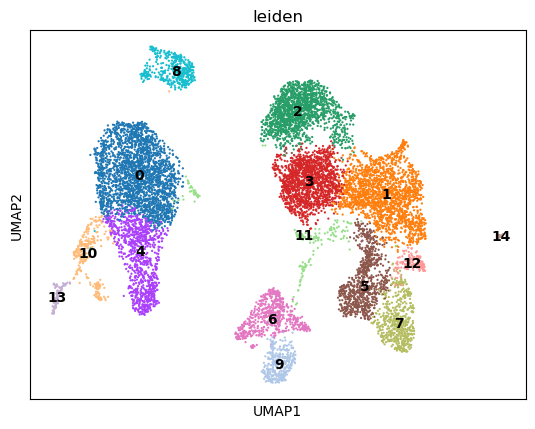

In [97]:
sc.pl.umap(rna, color="leiden", legend_loc="on data")

In [ ]:
Marker genes and celltypes

In [98]:
sc.tl.rank_genes_groups(rna, 'leiden', method='t-test')

In [99]:
result = rna.uns['rank_genes_groups']
groups = result['names'].dtype.names
pd.set_option('display.max_columns', 50)
pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals']}).head(10)

,0_n,0_p,1_n,1_p,2_n,2_p,3_n,3_p,4_n,4_p,5_n,5_p,6_n,6_p,7_n,7_p,8_n,8_p,9_n,9_p,10_n,10_p,11_n,11_p,12_n,12_p,13_n,13_p,14_n,14_p
0,PLXDC2,0.0,INPP4B,0.000000e+00,LEF1,0.0,LEF1,0.000000e+00,PSAP,0.0,CCL5,0.000000e+00,BANK1,0.000000e+00,GNLY,0.000000e+00,NEAT1,3.814409e-210,IGHM,1.865446e-274,CD74,5.106687e-184,RPS12,6.220734e-17,SLC4A10,8.366366e-60,TCF4,1.424239e-110,CDK6,1.042746e-13
1,DPYD,0.0,IL32,0.000000e+00,BACH2,0.0,BCL11B,0.000000e+00,TYMP,0.0,NKG7,2.465224e-260,RALGPS2,0.000000e+00,NKG7,1.775271e-279,PLXDC2,1.153562e-179,AFF3,3.358590e-268,HLA-DRA,1.157922e-139,RPS29,2.302700e-16,NKG7,3.183758e-50,RHEX,4.405926e-85,MAML3,6.821406e-13
2,VCAN,0.0,LTB,0.000000e+00,PDE3B,0.0,BACH2,0.000000e+00,LYN,0.0,IL32,4.838499e-268,CD74,0.000000e+00,CD247,4.647374e-287,ZEB2,5.139364e-165,BANK1,8.548581e-235,HLA-DRB1,4.545421e-119,RPS27,7.496666e-16,PHACTR2,3.315715e-45,FCHSD2,1.095430e-86,SOX4,1.456600e-12
3,NEAT1,0.0,SYNE2,0.000000e+00,THEMIS,0.0,FHIT,0.000000e+00,SLC8A1,0.0,SYNE2,1.037030e-200,AFF3,0.000000e+00,PRF1,6.186953e-226,LYST,9.539864e-151,CD74,1.177370e-237,AFF3,2.740893e-115,RPS14,2.504334e-14,SYNE2,1.736927e-42,IRF8,1.974946e-83,NKAIN2,4.956514e-12
4,ARHGAP26,0.0,ANK3,0.000000e+00,NELL2,0.0,CAMK4,0.000000e+00,SAT1,0.0,PRKCH,1.664599e-199,MS4A1,5.898180e-285,KLRD1,4.523149e-176,DPYD,4.096207e-154,HLA-DRA,2.666963e-179,HDAC9,2.112809e-115,RPL30,4.843263e-13,RORA,5.406976e-42,UGCG,1.264418e-77,RPLP0,1.187222e-11
5,LRMDA,0.0,IL7R,0.000000e+00,BCL11B,0.0,MALAT1,0.000000e+00,CD74,0.0,GZMA,4.743961e-167,OSBPL10,1.691742e-232,GZMA,1.323587e-173,SLC8A1,7.392239e-141,FCRL1,1.472297e-159,HLA-DQB1,2.224483e-108,RPL13,1.014829e-12,KLRB1,4.649232e-38,AFF3,4.724002e-78,RACK1,2.365501e-11
6,FCN1,0.0,CDC14A,0.000000e+00,CAMK4,0.0,RPS27A,0.000000e+00,TCF7L2,0.0,A2M,3.009152e-161,PAX5,5.373004e-228,SYNE1,1.122676e-166,TYMP,2.032428e-144,RALGPS2,7.553927e-157,HLA-DQA1,8.885470e-106,RPS21,8.421793e-11,CCL5,3.123908e-38,CD74,3.400064e-81,RNF220,6.095782e-11
7,ZEB2,0.0,ITGB1,1.378041e-314,OXNAD1,0.0,RPS27,2.394712e-299,ZEB2,0.0,SKAP1,9.385472e-175,CD79A,5.911879e-228,CTSW,1.347832e-159,LYN,1.212857e-140,BACH2,6.158729e-155,HLA-DPA1,9.855458e-101,RPL32,5.564455e-10,A2M,1.383393e-37,PLD4,2.398021e-71,ZNRF1,9.125698e-11
8,SLC8A1,0.0,BCL11B,0.000000e+00,CD8B,0.0,TCF7,2.878369e-267,CTSS,0.0,SYNE1,3.464176e-157,HLA-DRA,1.372362e-253,PRKCH,1.364390e-170,AOAH,2.471131e-140,PAX5,3.969755e-144,LYZ,2.426931e-101,RPL28,8.958434e-10,IL7R,1.886785e-37,RABGAP1L,5.710300e-74,RPS3A,1.477153e-10
9,JAK2,0.0,ARHGAP15,0.000000e+00,TXK,0.0,RPL3,9.932414e-293,WARS,0.0,HLA-B,2.504094e-151,BLK,7.644956e-199,MCTP2,7.709529e-155,FCN1,2.133089e-132,IGHD,2.107537e-127,HLA-DPB1,1.299288e-94,RPS26,1.099111e-09,SKAP1,1.016903e-37,ZFAT,7.479537e-69,EEF2,3.706137e-10


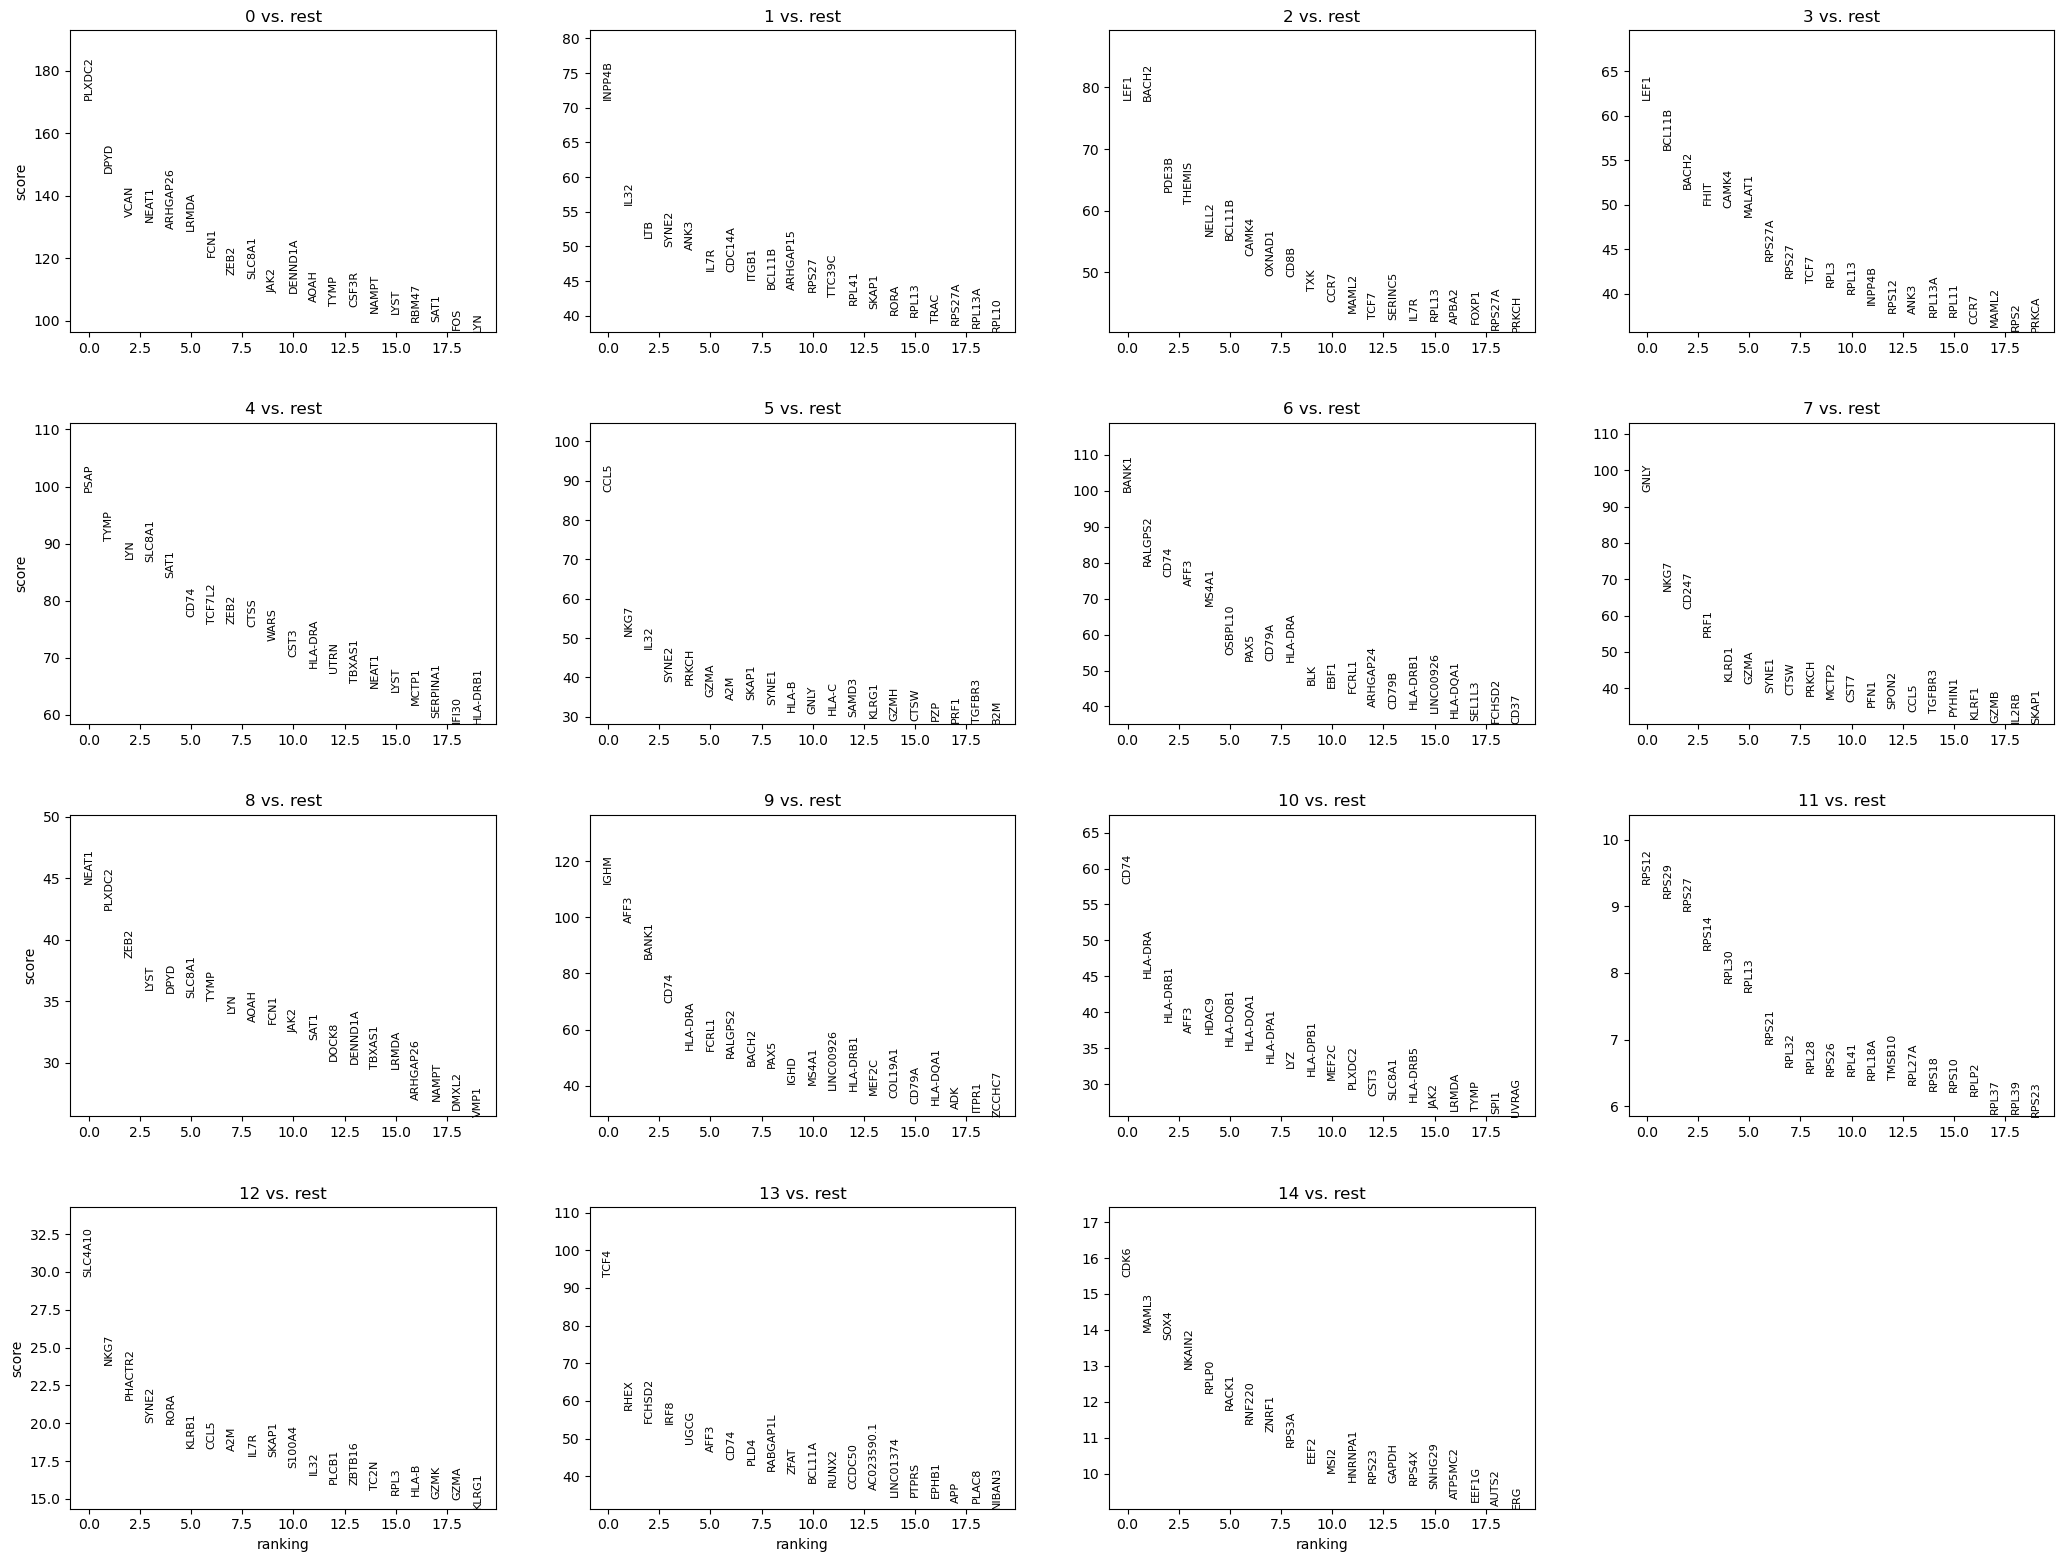

In [112]:
sc.pl.rank_genes_groups(rna, n_genes=20, sharey=False)

In [ ]:
Exploring the data we notice clusters 6 and 8 seem to be composed of cells bearing markers for different cell lineages so likely to be noise (e.g. doublets). Cluster 11 has higher ribosomal gene expression when compared to other clusters. Cluster 14 seem to consist of proliferating cells.

We will remove cells from these clusters before assigning cell types names to clusters.

In [113]:
mu.pp.filter_obs(rna, "leiden", lambda x: ~x.isin(["6", "8", "11", "14"]))
## Above removing for the tutorial, actual removal is below
# New Remove 8,6,14,11
## Old 9, 15, 16, 12
# Analogous to
#   rna = rna[~rna.obs.leiden.isin(["9", "15", "12", "16"])]
# but doesn't copy the object

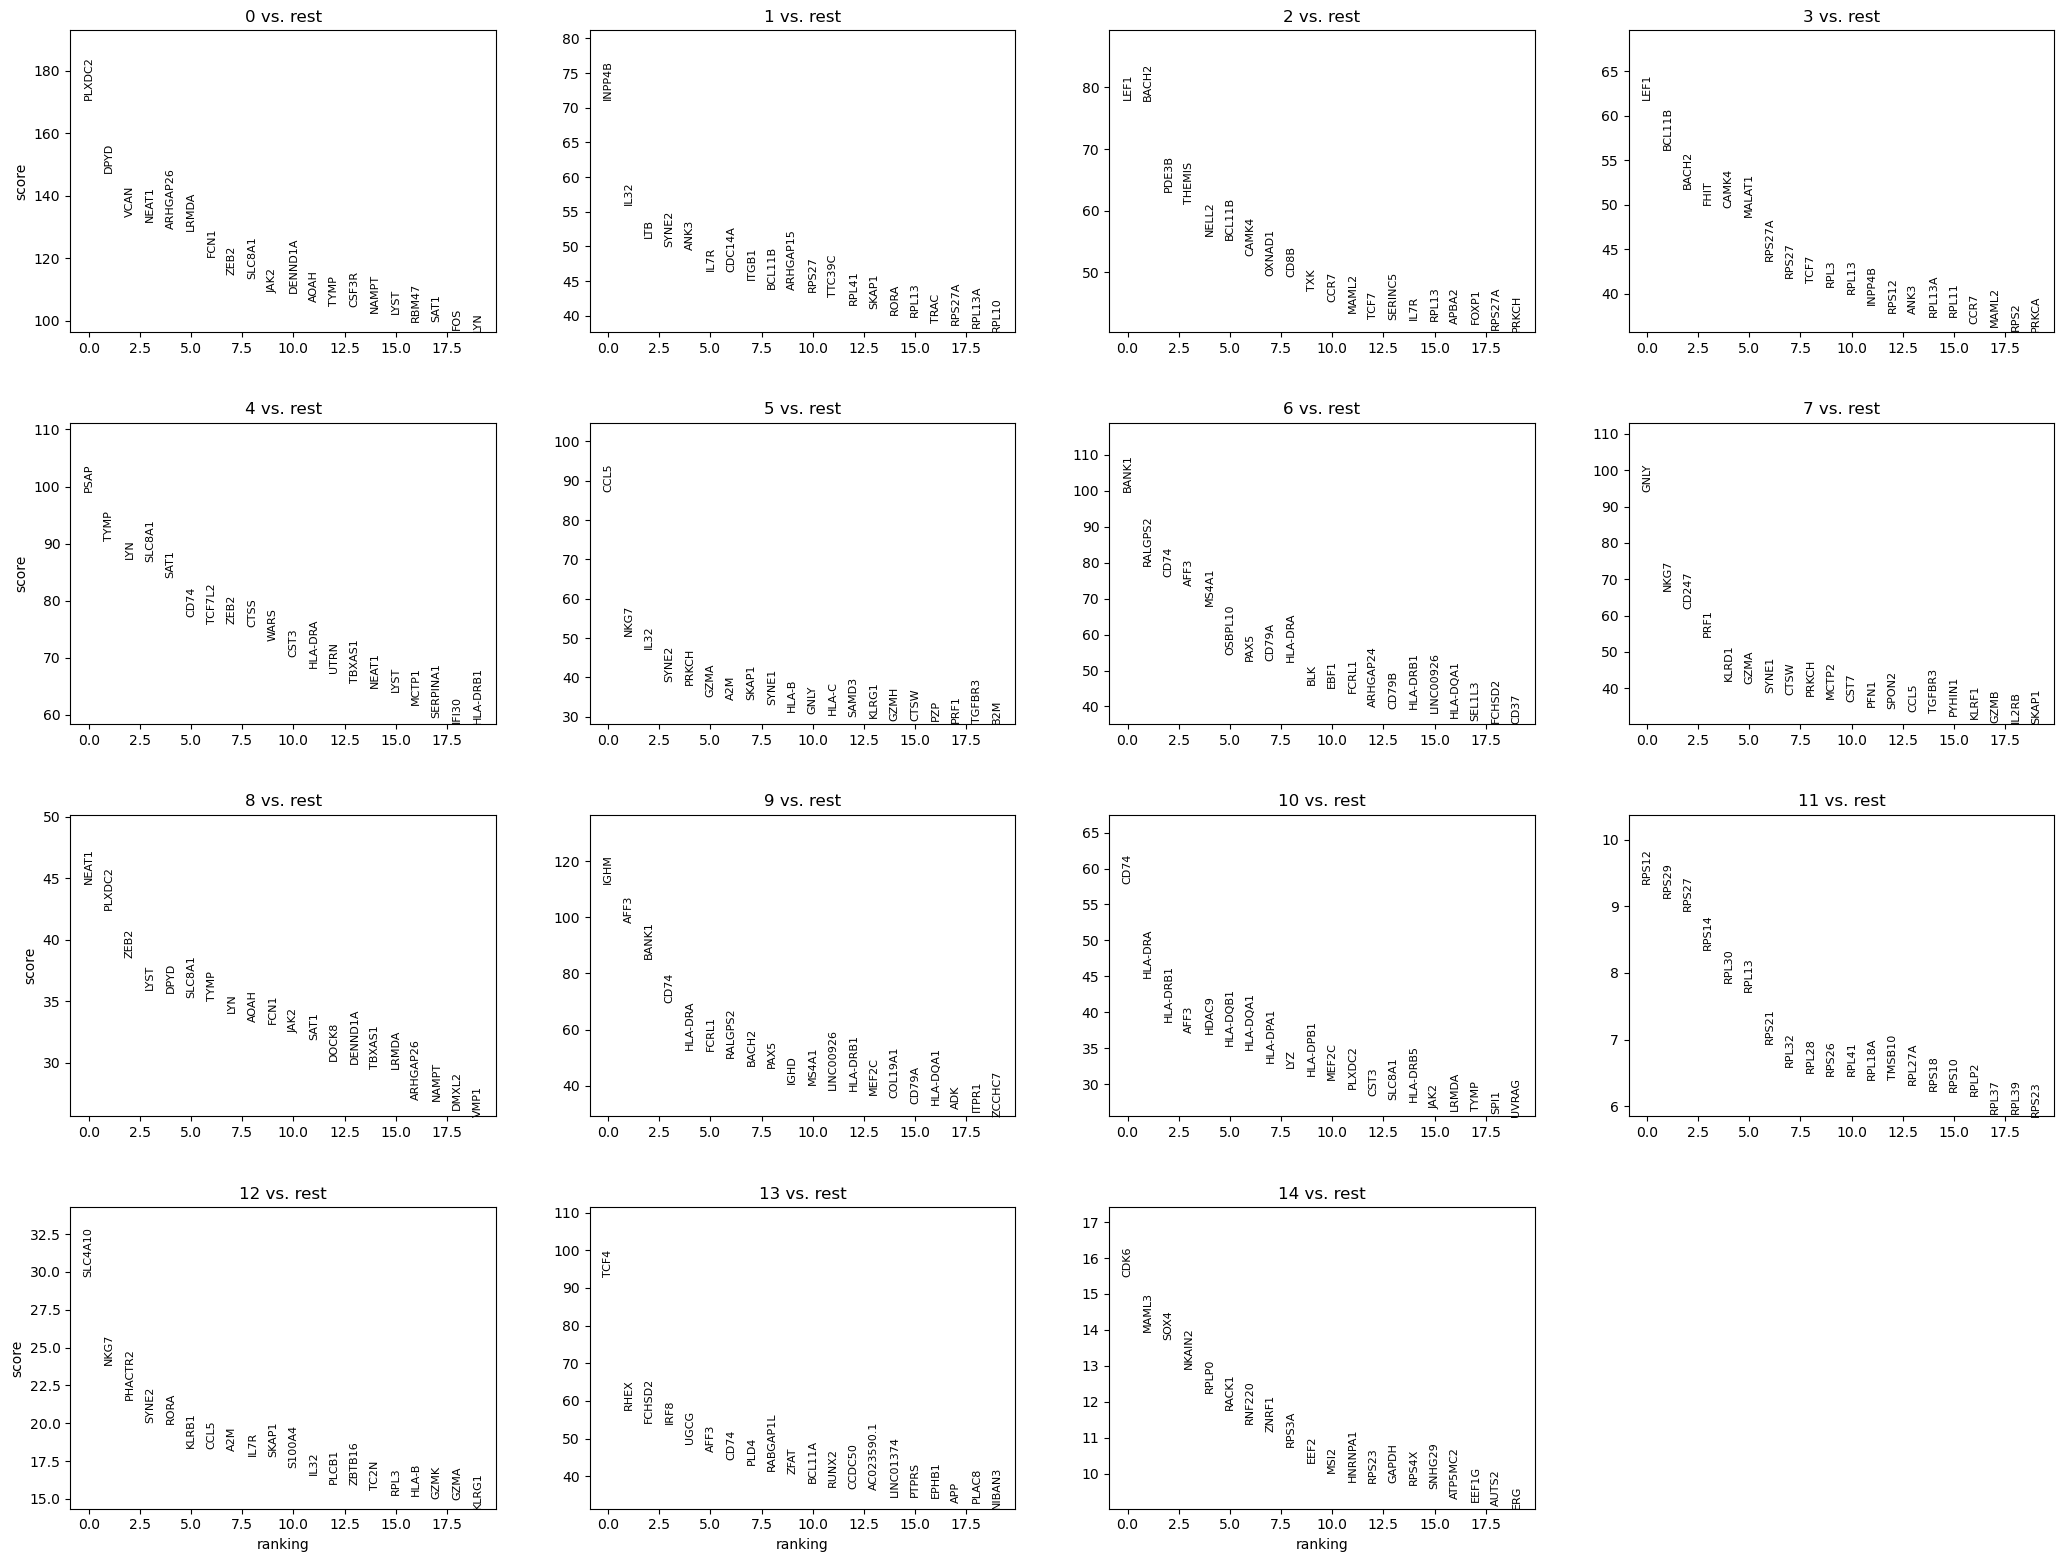

In [114]:
sc.pl.rank_genes_groups(rna, n_genes=20, sharey=False)

In [121]:
new_cluster_names = {
    "0": "CD14 mono",
    "1": "CD4+ memory T",
    "2": "CD8+ naïve T",
    "3": "CD4+ naïve T",
    "4": "CD16 mono",
    "5": "CD8+ activated T",
    "6": "memory B",
    "7": "NK",
    "9": "naive B",
    "10": "mDC",
    "12": "MAIT",
    "13": "pDC",
    "6":  "NA",
    "8": "NA",
    "11": "NA",
    "14": "NA"
}

rna.obs['celltype'] = rna.obs.leiden.astype("str").values
rna.obs.celltype = rna.obs.celltype.astype("category")
rna.obs.celltype = rna.obs.celltype.cat.rename_categories(new_cluster_names)

In [122]:
rna.obs['leiden'].value_counts()

leiden
0     2342
1     1818
2     1566
3     1500
4      948
5      801
7      551
10     281
13     112
6        0
8        0
9        0
11       0
12       0
14       0
Name: count, dtype: int64

In [123]:
rna.obs['celltype'] 
rna.obs['celltype'].value_counts()


celltype
CD14 mono           2342
CD4+ memory T       1818
CD8+ naïve T        1566
CD4+ naïve T        1500
CD16 mono            948
CD8+ activated T     801
NK                   551
mDC                  281
pDC                  112
Name: count, dtype: int64

In [124]:
rna.obs.celltype.cat.reorder_categories([
    'CD4+ naïve T', 'CD4+ memory T',
    'CD8+ naïve T', 'CD8+ activated T', 'NK',
    'CD14 mono', 'CD16 mono',
    'mDC', 'pDC'], ordered=True)

AAACAGCCAAGGAATC-1        CD8+ naïve T
AAACAGCCAATCCCTT-1       CD4+ memory T
AAACAGCCAATGCGCT-1        CD4+ naïve T
AAACAGCCACCAACCG-1        CD8+ naïve T
AAACAGCCAGGATAAC-1        CD4+ naïve T
                            ...       
TTTGTTGGTGTTAAAC-1        CD8+ naïve T
TTTGTTGGTTAGGATT-1                  NK
TTTGTTGGTTGCAGTA-1       CD4+ memory T
TTTGTTGGTTGGTTAG-1       CD4+ memory T
TTTGTTGGTTTGCAGA-1    CD8+ activated T
Name: celltype, Length: 9919, dtype: category
Categories (9, object): ['CD4+ naïve T' < 'CD4+ memory T' < 'CD8+ naïve T' < 'CD8+ activated T' ... 'CD14 mono' < 'CD16 mono' < 'mDC' < 'pDC']

In [125]:
import matplotlib
import matplotlib.pyplot as plt

cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0, 1, len(rna.obs.celltype.cat.categories)))

rna.uns["celltype_colors"] = list(map(matplotlib.colors.to_hex, colors))

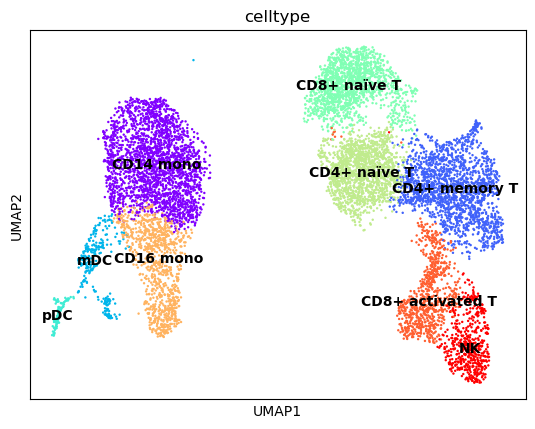

In [126]:
sc.pl.umap(rna, color="celltype", legend_loc="on data")

In [127]:
marker_genes = ['IL7R', 'TRAC',
                'ITGB1', # CD29
                'SLC4A10',
                'CD8A', 'CD8B', 'CCL5',
                'GNLY', 'NKG7',
                'CD79A', 'MS4A1', 'IGHM', 'IGHD',
                'IL4R', 'TCL1A',
                'KLF4', 'LYZ', 'S100A8', 'ITGAM', # CD11b
                'CD14', 'FCGR3A', 'MS4A7',
                'CST3', 'CLEC10A', 'IRF8', 'TCF4']

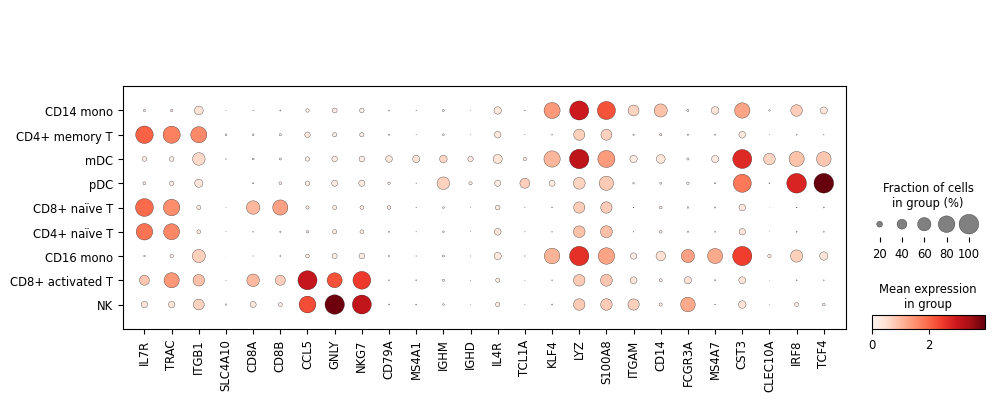

In [128]:
sc.pl.dotplot(rna, marker_genes, groupby='celltype');

In [129]:
mdata = mu.MuData({"rna": rna})
mu.write("/Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/pbmc_integration/rna.h5mu", mdata)

/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/mudat